# Flight Ticket Dynamic Pricing with LSTM
### CRISP-DM Framework

---

**CRISP-DM Phases covered in this notebook:**

| Phase | Description |
|---|---|
| 1. Business Understanding | Define the pricing problem |
| 2. Data Understanding | Explore and visualize the data |
| 3. Data Preparation | Clean, encode, and scale features |
| 4. Modeling | Build and train the LSTM model |
| 5. Evaluation | Assess model performance |
| 6. Deployment | Save model and predict new prices |


---
## Phase 1 — Business Understanding

**Problem Statement:**  
Airlines use dynamic pricing — ticket prices change based on demand, time to departure, route, and other factors. Our goal is to **predict the ticket price** given flight attributes, enabling smarter pricing decisions.

**Business Questions:**
- How do prices change as departure approaches (`days_left`)?
- Which airlines/routes command the highest prices?
- Can an LSTM model learn temporal pricing patterns?

**Target Variable:** `price` (continuous — regression task)  
**Key Driver:** `days_left` (temporal signal that makes LSTM a natural fit)


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

# Clone repo
os.chdir('/content')
!git clone https://github.com/VAL-Jerono/Dynamic_Pricing.git 2>/dev/null || \
(cd Dynamic_Pricing && git pull)

# Repo code
os.chdir('/content/Dynamic_Pricing')
sys.path.insert(0, 'src')

# Data path
DATA_PATH = "/content/drive/MyDrive/DYNAMIC PRICING/DATA SETS"



data = pd.read_csv("/content/drive/MyDrive/DYNAMIC PRICING/DATA SETS/FLIGHTS DATA SETS/flight_data_cleaned.csv")
data.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Already up to date.


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_category
0,SpiceJet,1408,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Medium
1,SpiceJet,1387,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Long
2,AirAsia,1213,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Medium
3,Vistara,1559,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Medium
4,Vistara,1549,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Long
5,Vistara,1541,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,Long
6,Vistara,1533,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060,Short
7,Vistara,1543,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060,Medium
8,GO_FIRST,1013,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954,Medium
9,GO_FIRST,1014,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954,Medium


---
## Phase 2 — Data Understanding
### 2.1 — Imports & Setup

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Preprocessing
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib  # for saving encoders/scalers

print(f"TensorFlow version: {tf.__version__}")
print(" All libraries loaded successfully")

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

TensorFlow version: 2.19.0
 All libraries loaded successfully


### 2.2 — Load Data

In [9]:
#data = pd.read_csv("/content/drive/MyDrive/flight_data_cleaned.csv")

print(f"Shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
data.head(10)

Shape: (300153, 12)

Columns: ['airline', 'flight', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class', 'duration', 'days_left', 'price', 'duration_category']


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_category
0,SpiceJet,1408,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Medium
1,SpiceJet,1387,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Long
2,AirAsia,1213,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Medium
3,Vistara,1559,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Medium
4,Vistara,1549,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Long
5,Vistara,1541,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.33,1,5955,Long
6,Vistara,1533,Delhi,Morning,zero,Morning,Mumbai,Economy,2.08,1,6060,Short
7,Vistara,1543,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.17,1,6060,Medium
8,GO_FIRST,1013,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.17,1,5954,Medium
9,GO_FIRST,1014,Delhi,Afternoon,zero,Evening,Mumbai,Economy,2.25,1,5954,Medium


### 2.3 — Basic Statistics

In [10]:
print("=== Data Types ===")
print(data.dtypes)

print("\n=== Missing Values ===")
print(data.isnull().sum())

print("\n=== Target Variable (price) Stats ===")
print(data['price'].describe())

=== Data Types ===
airline               object
flight                 int64
source_city           object
departure_time        object
stops                 object
arrival_time          object
destination_city      object
class                 object
duration             float64
days_left              int64
price                  int64
duration_category     object
dtype: object

=== Missing Values ===
airline              0
flight               0
source_city          0
departure_time       0
stops                0
arrival_time         0
destination_city     0
class                0
duration             0
days_left            0
price                0
duration_category    0
dtype: int64

=== Target Variable (price) Stats ===
count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


### 2.4 — Exploratory Visualizations

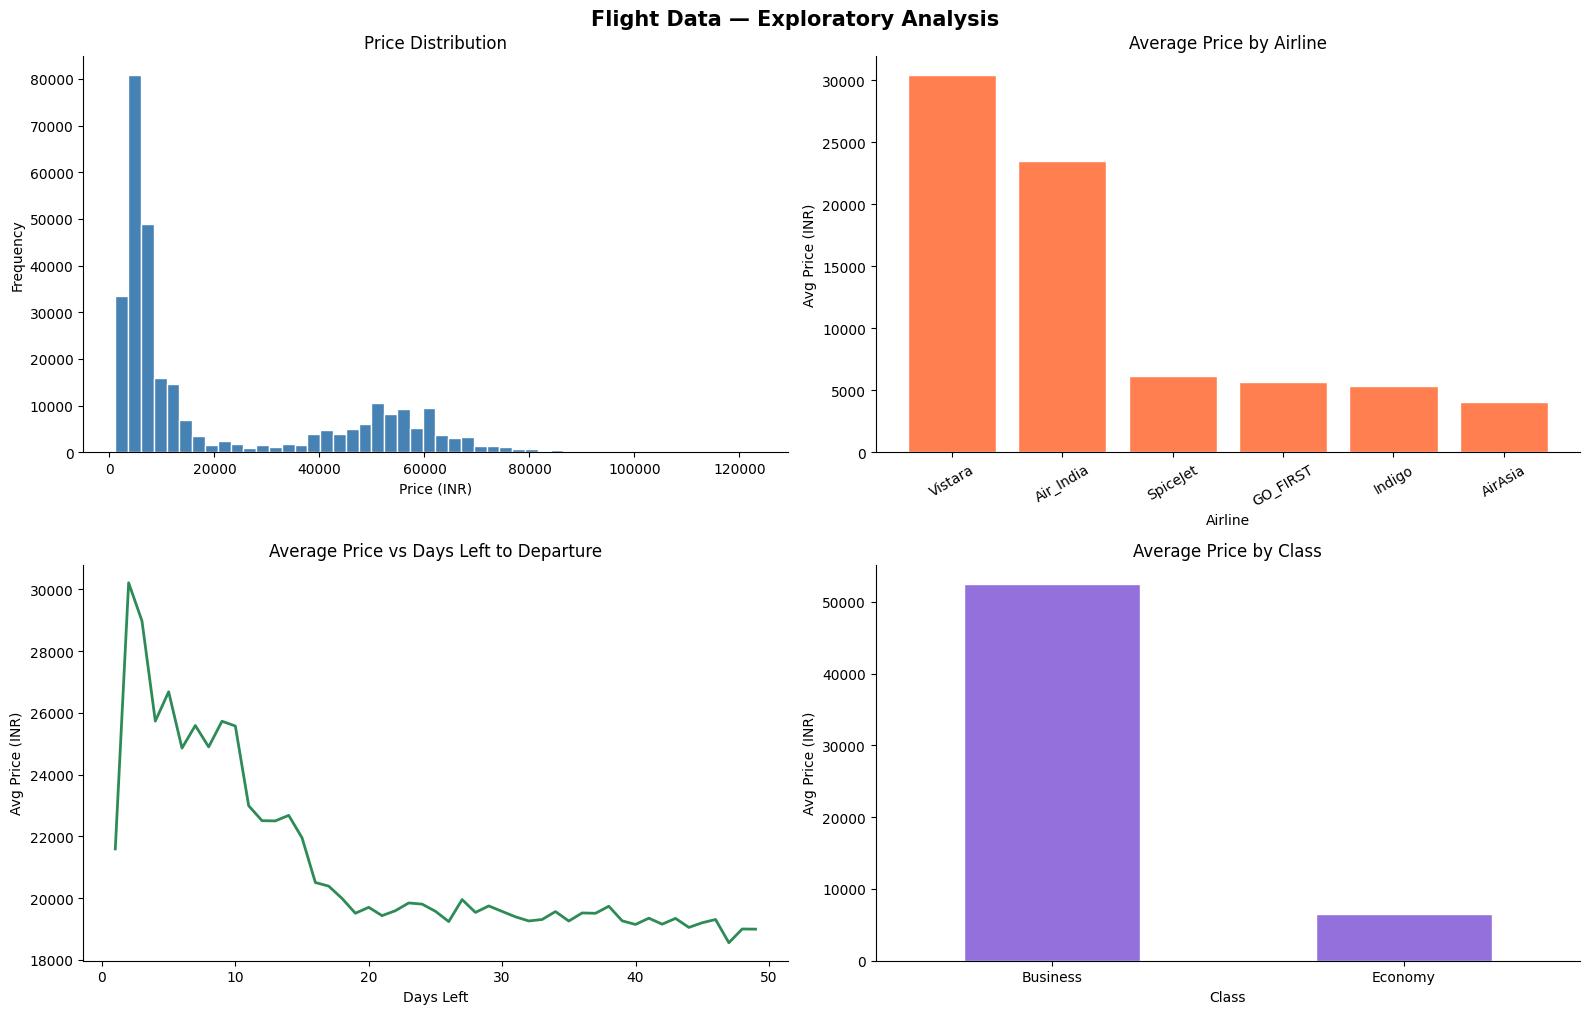

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Price distribution
axes[0, 0].hist(data['price'], bins=50, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (INR)')
axes[0, 0].set_ylabel('Frequency')

# 2. Average price by airline
airline_avg = data.groupby('airline')['price'].mean().sort_values(ascending=False)
axes[0, 1].bar(airline_avg.index, airline_avg.values, color='coral', edgecolor='white')
axes[0, 1].set_title('Average Price by Airline')
axes[0, 1].set_xlabel('Airline')
axes[0, 1].set_ylabel('Avg Price (INR)')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Price vs days_left (the temporal signal)
days_avg = data.groupby('days_left')['price'].mean().reset_index()
axes[1, 0].plot(days_avg['days_left'], days_avg['price'], color='seagreen', linewidth=2)
axes[1, 0].set_title('Average Price vs Days Left to Departure')
axes[1, 0].set_xlabel('Days Left')
axes[1, 0].set_ylabel('Avg Price (INR)')

# 4. Price by class
data.groupby('class')['price'].mean().plot(kind='bar', ax=axes[1, 1], color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('Average Price by Class')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Avg Price (INR)')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.suptitle('Flight Data — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.show()

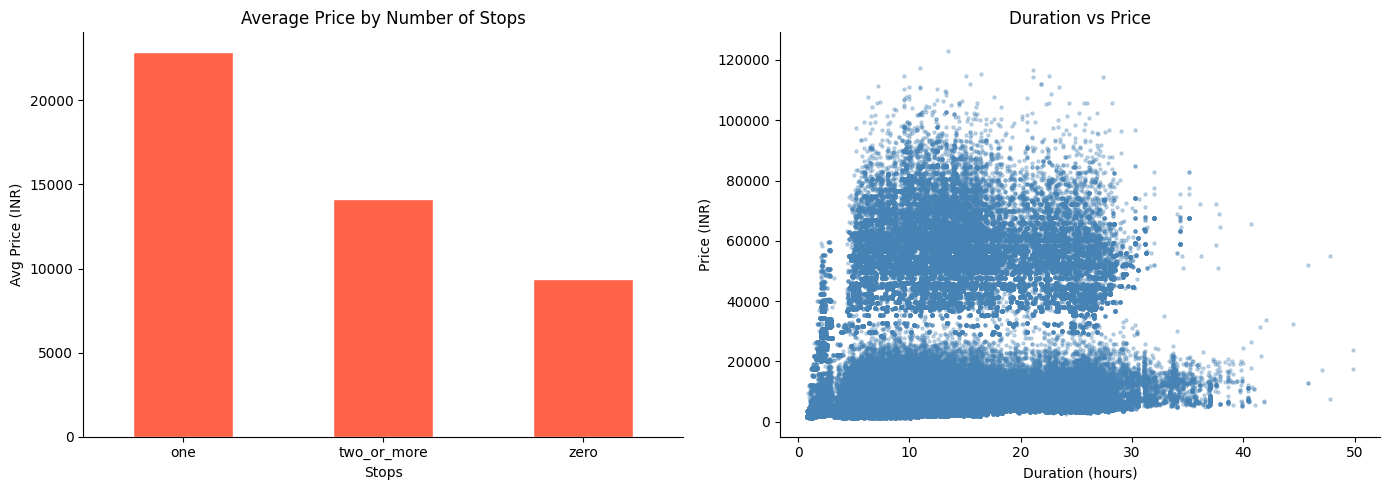

In [12]:
# Stops vs Price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data.groupby('stops')['price'].mean().plot(kind='bar', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Average Price by Number of Stops')
axes[0].set_xlabel('Stops')
axes[0].set_ylabel('Avg Price (INR)')
axes[0].tick_params(axis='x', rotation=0)

# Duration vs Price scatter
axes[1].scatter(data['duration'], data['price'], alpha=0.3, color='steelblue', s=5)
axes[1].set_title('Duration vs Price')
axes[1].set_xlabel('Duration (hours)')
axes[1].set_ylabel('Price (INR)')

plt.tight_layout()
plt.show()

---
## Phase 3 — Data Preparation
### 3.1 — Encode Categorical Variables

LSTM works with numbers. We'll label-encode all string columns and save the encoders for later use (deployment).

In [26]:
df = data.copy()

# Columns to encode
categorical_cols = ['airline', 'source_city', 'departure_time', 'stops',
                    'arrival_time', 'destination_city', 'class', 'duration_category']

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"  {col}: {le.classes_}")

# Drop non-predictive column
df = df.drop(columns=['flight'], errors='ignore')

print("\n Encoding complete")
df.head()

  airline: ['AirAsia' 'Air_India' 'GO_FIRST' 'Indigo' 'SpiceJet' 'Vistara']
  source_city: ['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Kolkata' 'Mumbai']
  departure_time: ['Afternoon' 'Early_Morning' 'Evening' 'Late_Night' 'Morning' 'Night']
  stops: ['one' 'two_or_more' 'zero']
  arrival_time: ['Afternoon' 'Early_Morning' 'Evening' 'Late_Night' 'Morning' 'Night']
  destination_city: ['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Kolkata' 'Mumbai']
  class: ['Business' 'Economy']
  duration_category: ['Long' 'Medium' 'Short']

 Encoding complete


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_category
0,4,2,2,2,5,5,1,2.17,1,5953,1
1,4,2,1,2,4,5,1,2.33,1,5953,0
2,0,2,1,2,1,5,1,2.17,1,5956,1
3,5,2,4,2,0,5,1,2.25,1,5955,1
4,5,2,4,2,4,5,1,2.33,1,5955,0


### 3.2 — Feature Selection & Scaling

In [14]:
# Define features and target
feature_cols = ['airline', 'source_city', 'departure_time', 'stops',
                'arrival_time', 'destination_city', 'class',
                'duration', 'days_left', 'duration_category']

X = df[feature_cols].values
y = df['price'].values

# Scale features to [0, 1]
feature_scaler = MinMaxScaler()
X_scaled = feature_scaler.fit_transform(X)

# Scale target (helps LSTM learn faster)
price_scaler = MinMaxScaler()
y_scaled = price_scaler.fit_transform(y.reshape(-1, 1)).flatten()

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Target array shape:   {y_scaled.shape}")
print(f"Price range (original): {y.min():,.0f} — {y.max():,.0f} INR")
print(f"Price range (scaled):   {y_scaled.min():.3f} — {y_scaled.max():.3f}")

Feature matrix shape: (300153, 10)
Target array shape:   (300153,)
Price range (original): 1,105 — 123,071 INR
Price range (scaled):   0.000 — 1.000


### 3.3 — Reshape for LSTM

LSTM expects input shape: `(samples, timesteps, features)`.  

Since each flight row is independent, we use `timesteps = 1` — the LSTM still learns non-linear feature interactions. For true time-series per route, you would group by route and sort by `days_left`.

In [27]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Reshape: (samples, timesteps=1, features)
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm  = X_test.reshape((X_test.shape[0],  1, X_test.shape[1]))

print(f"Train set: {X_train_lstm.shape}  |  {y_train.shape}")
print(f"Test set:  {X_test_lstm.shape}   |  {y_test.shape}")
print(" Data ready for LSTM")

Train set: (240122, 1, 10)  |  (240122,)
Test set:  (60031, 1, 10)   |  (60031,)
 Data ready for LSTM


---
## Phase 4 — Modeling
### 4.1 — Build the LSTM Model

Architecture:
- Two stacked LSTM layers with dropout for regularization
- Batch Normalization for training stability
- Dense output layer (regression)

In [16]:
n_features = X_train_lstm.shape[2]

model = Sequential([
    # First LSTM layer — return sequences for stacking
    LSTM(128, return_sequences=True, input_shape=(1, n_features)),
    Dropout(0.3),
    BatchNormalization(),

    # Second LSTM layer
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),

    # Dense layers
    Dense(32, activation='relu'),
    Dropout(0.1),

    # Output layer (regression — no activation)
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,457 (482.25 KB)

 Trainable params: 123,073 (480.75 KB)

 Non-trainable params: 384 (1.50 KB)

### 4.2 — Train the Model

In [17]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=256,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n Training complete. Best epoch: {np.argmin(history.history['val_loss']) + 1}")

Epoch 1/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - loss: 0.0472 - mae: 0.1364 - val_loss: 0.0057 - val_mae: 0.0522 - learning_rate: 0.0010
Epoch 2/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0047 - mae: 0.0465 - val_loss: 0.0024 - val_mae: 0.0311 - learning_rate: 0.0010
Epoch 3/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 0.0034 - mae: 0.0382 - val_loss: 0.0024 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 4/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0031 - mae: 0.0358 - val_loss: 0.0026 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 5/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0029 - mae: 0.0346 - val_loss: 0.0021 - val_mae: 0.0282 - learning_rate: 0.0010
Epoch 6/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0028 - mae: 0.0337 - val_loss: 0.0021 - val_mae: 0.0280 - learning_rate: 0.0010
Epoch 7/100
798/798 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0026 - mae: 0.0329 - val_loss: 0.0020 - val_mae: 0.0276 - learnin

### 4.3 — Training Curves

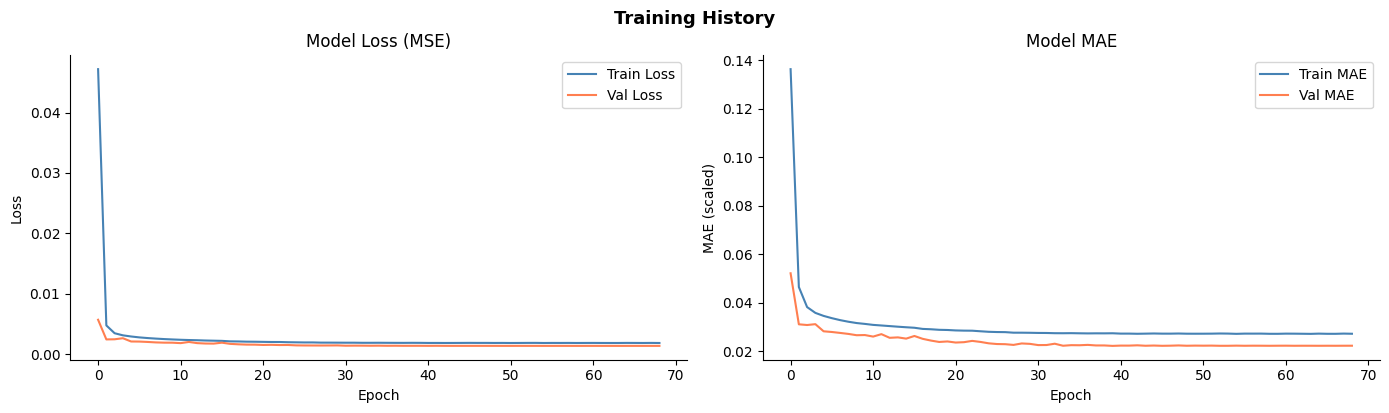

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Model Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE
axes[1].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Model MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (scaled)')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Training History', fontsize=13, fontweight='bold', y=1.02)
plt.show()

---
## Phase 5 — Evaluation
### 5.1 — Metrics on Test Set

In [19]:
# Predict on test set
y_pred_scaled = model.predict(X_test_lstm).flatten()

# Inverse transform to original price scale
y_pred = price_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = price_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Metrics
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("="*40)
print("  MODEL PERFORMANCE (Test Set)")
print("="*40)
print(f"  MAE  : ₹{mae:>10,.2f}")
print(f"  RMSE : ₹{rmse:>10,.2f}")
print(f"  MAPE :  {mape:>9.2f}%")
print(f"  R²   :  {r2:>9.4f}")
print("="*40)

1876/1876 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step
  MODEL PERFORMANCE (Test Set)
  MAE  : ₹  2,707.62
  RMSE : ₹  4,495.68
  MAPE :      21.28%
  R²   :     0.9608


### 5.2 — Actual vs Predicted Plot

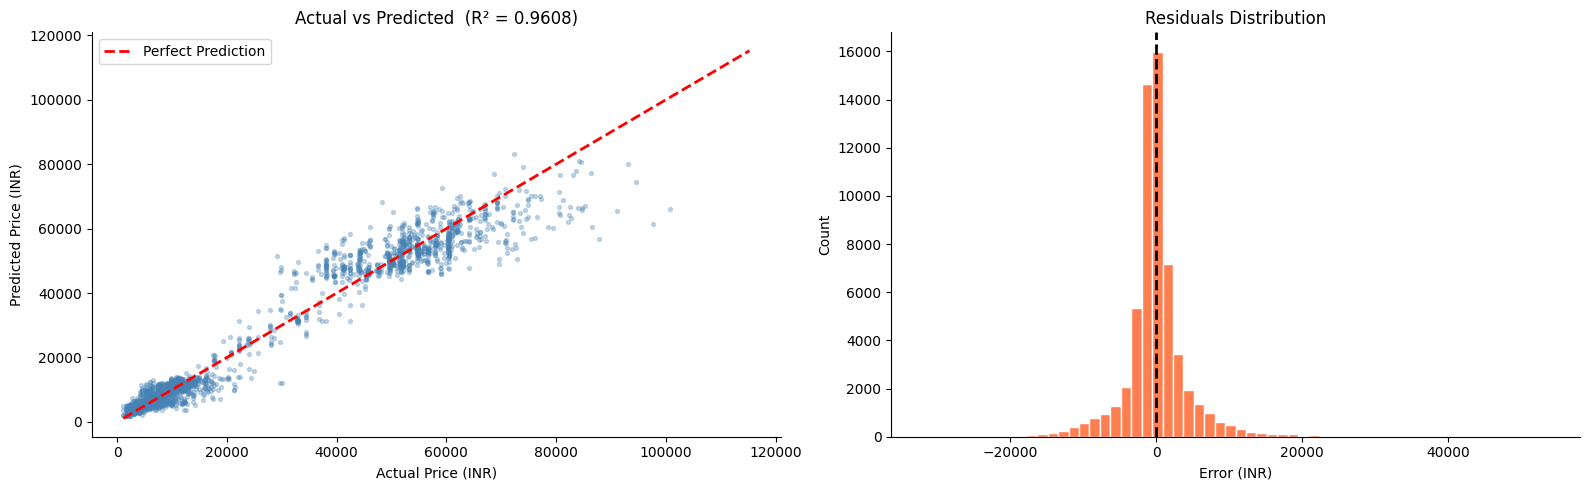

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter: actual vs predicted
sample_idx = np.random.choice(len(y_true), min(3000, len(y_true)), replace=False)
axes[0].scatter(y_true[sample_idx], y_pred[sample_idx], alpha=0.3, s=8, color='steelblue')
min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f'Actual vs Predicted  (R² = {r2:.4f})')
axes[0].set_xlabel('Actual Price (INR)')
axes[0].set_ylabel('Predicted Price (INR)')
axes[0].legend()

# Residuals
residuals = y_true - y_pred
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Error (INR)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 5.3 — Price Prediction by Days Left (Temporal Insight)

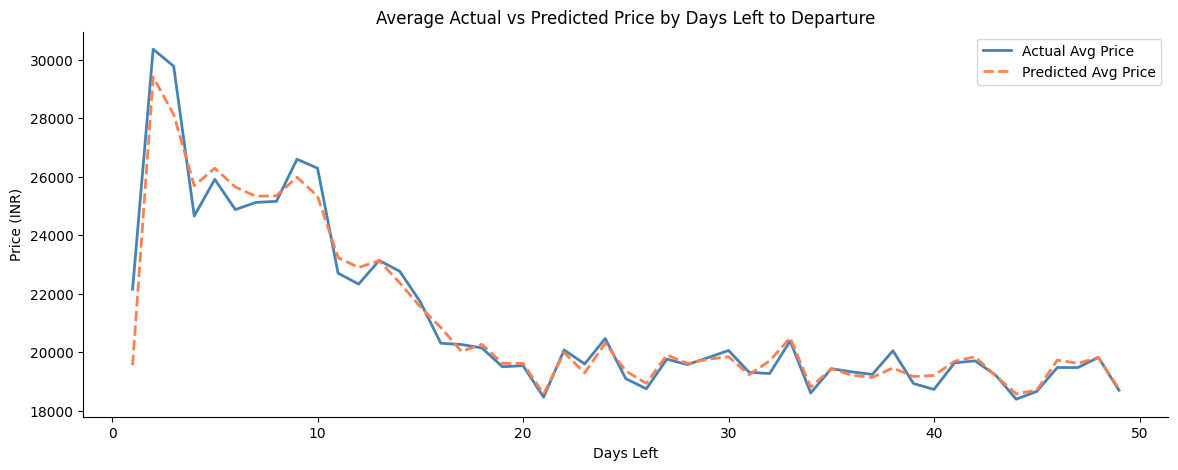


Insight: The model captures the temporal pricing trend as departure approaches.


In [31]:
# Reconstruct test DataFrame for analysis
test_idx = np.arange(len(X_test))
X_test_orig = feature_scaler.inverse_transform(X_test)
days_left_test = X_test_orig[:, feature_cols.index('days_left')]

analysis_df = pd.DataFrame({
    'days_left': days_left_test.round().astype(int),
    'actual': y_true,
    'predicted': y_pred
})

grouped = analysis_df.groupby('days_left')[['actual', 'predicted']].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(grouped['days_left'], grouped['actual'],    label='Actual Avg Price',    color='steelblue', lw=2)
plt.plot(grouped['days_left'], grouped['predicted'], label='Predicted Avg Price', color='coral',     lw=2, linestyle='--')
plt.title('Average Actual vs Predicted Price by Days Left to Departure')
plt.xlabel('Days Left')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

print("\nInsight: The model captures the temporal pricing trend as departure approaches.")

---
## Phase 6 — Deployment
### 6.1 — Save the Model and Artifacts

In [30]:
import os

save_dir = "/content/drive/MyDrive/dynamic_pricing_model"
os.makedirs(save_dir, exist_ok=True)

# Save Keras model
model.save(f"{save_dir}/lstm_pricing_model.h5")

# Save scalers and encoders
joblib.dump(feature_scaler, f"{save_dir}/feature_scaler.pkl")
joblib.dump(price_scaler,   f"{save_dir}/price_scaler.pkl")
joblib.dump(encoders,       f"{save_dir}/label_encoders.pkl")

print(f" Model saved to: {save_dir}")
print("   - lstm_pricing_model.h5")
print("   - feature_scaler.pkl")
print("   - price_scaler.pkl")
print("   - label_encoders.pkl")

 Model saved to: /content/drive/MyDrive/dynamic_pricing_model
   - lstm_pricing_model.h5
   - feature_scaler.pkl
   - price_scaler.pkl
   - label_encoders.pkl


### 6.2 — Predict Price for a New Flight

This is the deployment-ready prediction function. Given any flight's attributes, it returns the predicted price.

In [28]:
def predict_price(flight_details: dict) -> float:
    """
    Predict ticket price for a new flight.

    Parameters
    ----------
    flight_details : dict
        Keys: airline, source_city, departure_time, stops, arrival_time,
              destination_city, class, duration, days_left, duration_category

    Returns
    -------
    float : Predicted price in INR
    """
    row = []
    for col in feature_cols:
        val = flight_details[col]
        if col in encoders:
            val = encoders[col].transform([str(val)])[0]
        row.append(val)

    X_new = np.array(row).reshape(1, -1)
    X_new_scaled = feature_scaler.transform(X_new)
    X_new_lstm = X_new_scaled.reshape(1, 1, X_new_scaled.shape[1])

    pred_scaled = model.predict(X_new_lstm, verbose=0)
    pred_price = price_scaler.inverse_transform(pred_scaled)[0][0]

    return round(pred_price, 2)


# ---- Example prediction ----
sample_flight = {
    'airline':           'Vistara',
    'source_city':       'Delhi',
    'departure_time':    'Morning',
    'stops':             'zero',
    'arrival_time':      'Afternoon',
    'destination_city':  'Mumbai',
    'class':             'Economy',
    'duration':          2.25,
    'days_left':         15,
    'duration_category': 'Medium'
}

predicted = predict_price(sample_flight)
print(f"Flight: {sample_flight['airline']} | {sample_flight['source_city']} → {sample_flight['destination_city']}")
print(f" Days to departure: {sample_flight['days_left']}")
print(f"Predicted Price:   ₹{predicted:,.2f}")

Flight: Vistara | Delhi → Mumbai
 Days to departure: 15
Predicted Price:   ₹4,844.78


### 6.3 — Price Sensitivity: Days Left Analysis

How does the predicted price change as we approach the departure date for this same flight?

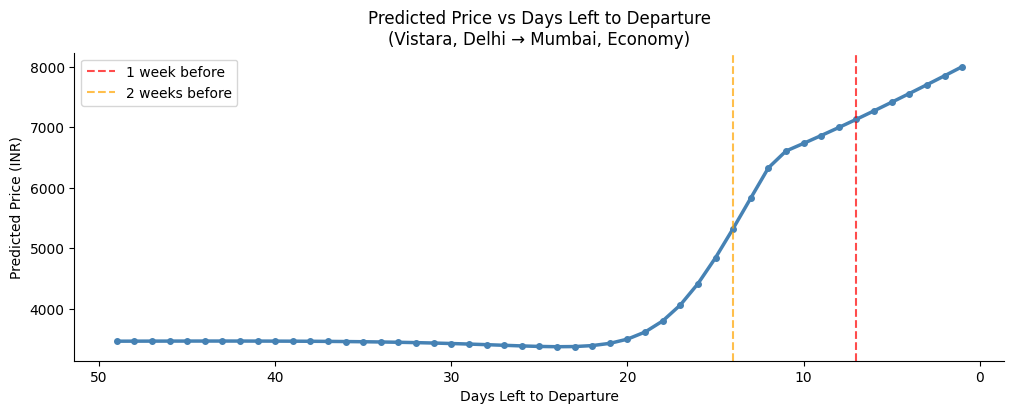


Price range: ₹3,373 (farthest) → ₹8,003 (closest to departure)


In [29]:
days_range = list(range(1, 50))
prices = []

for d in days_range:
    flight = sample_flight.copy()
    flight['days_left'] = d
    prices.append(predict_price(flight))

plt.figure(figsize=(12, 4))
plt.plot(days_range, prices, color='steelblue', lw=2.5, marker='o', markersize=4)
plt.axvline(x=7,  color='red',    linestyle='--', alpha=0.7, label='1 week before')
plt.axvline(x=14, color='orange', linestyle='--', alpha=0.7, label='2 weeks before')
plt.title('Predicted Price vs Days Left to Departure\n(Vistara, Delhi → Mumbai, Economy)')
plt.xlabel('Days Left to Departure')
plt.ylabel('Predicted Price (INR)')
plt.legend()
plt.gca().invert_xaxis()  # Closer to departure = right side
plt.show()

print(f"\nPrice range: ₹{min(prices):,.0f} (farthest) → ₹{max(prices):,.0f} (closest to departure)")

---
## Summary

| CRISP-DM Phase | What we did |
|---|---|
| **Business Understanding** | Framed ticket price prediction as a dynamic pricing regression problem |
| **Data Understanding** | Explored distributions, airline averages, and the `days_left` temporal trend |
| **Data Preparation** | Label-encoded categoricals, MinMax-scaled features and target, reshaped for LSTM |
| **Modeling** | Built a 2-layer stacked LSTM with BatchNorm + Dropout; trained with EarlyStopping |
| **Evaluation** | Assessed MAE, RMSE, MAPE, R² on held-out test set; visualized residuals |
| **Deployment** | Saved model + artifacts; built `predict_price()` function + sensitivity analysis |

**Next Steps:**
- Group data by route + sort by `days_left` for true sequential LSTM time-series modeling
- Add feature engineering: day-of-week, holiday flags, route demand proxies
- Experiment with Transformer-based architectures for even better temporal modelling
- Wrap `predict_price()` in a REST API (FastAPI / Flask) for real-time pricing